<a href="https://colab.research.google.com/github/Jeevith252/ML_BASIC_PROJECT/blob/main/ML_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_score
)

In [2]:
!pip install xgboost lightgbm -q

In [3]:
data =load_breast_cancer(as_frame=True)
df = data.frame

In [4]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
X = df.drop("target",axis = 1)
y = df["target"]

X_train ,X_test , y_train ,y_test = train_test_split(X , y , test_size=0.2 , random_state= 42,stratify= y)


In [6]:
rf = RandomForestClassifier()
rf.fit(X_train , y_train)
rf_prediction = rf.predict(X_test)

In [7]:
print("Accuracy Score : " , accuracy_score(y_test ,rf_prediction))
print("Classification Report : \n" , classification_report(y_test ,rf_prediction))

Accuracy Score :  0.9473684210526315
Classification Report : 
               precision    recall  f1-score   support

           0       0.93      0.93      0.93        42
           1       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



In [8]:
xgb = XGBClassifier()
xgb.fit(X_train , y_train)
xgb_pred = xgb.predict(X_test)

In [9]:
print("Accuracy Score : " , accuracy_score(y_test ,xgb_pred))
print("Classification Report : \n" , classification_report(y_test ,xgb_pred))

Accuracy Score :  0.956140350877193
Classification Report : 
               precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [10]:
lg = LGBMClassifier()
lg.fit(X_train , y_train)
lg_pred = lg.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 285, number of negative: 170
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000403 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4542
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.626374 -> initscore=0.516691
[LightGBM] [Info] Start training from score 0.516691
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

In [11]:
print("Accuracy Score : " , accuracy_score(y_test ,lg_pred))
print("Classification Report : \n" , classification_report(y_test ,lg_pred))

Accuracy Score :  0.9649122807017544
Classification Report : 
               precision    recall  f1-score   support

           0       0.97      0.93      0.95        42
           1       0.96      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [12]:
comparison = pd.DataFrame({
    "model": ["Random Forest", "XGBoost" , "LightGBM"],
    "Accuracy" : [accuracy_score(y_test ,rf_prediction) , accuracy_score(y_test ,xgb_pred),accuracy_score(y_test ,lg_pred)]
})

In [13]:
comparison

,model,Accuracy
0,Random Forest,0.947368
1,XGBoost,0.956140
2,LightGBM,0.964912


In [14]:
train_df = pd.read_csv("/content/customer_churn_dataset-training-master.csv")
test_df = pd.read_csv("/content/customer_churn_dataset-testing-master.csv")

In [15]:
print(train_df["Churn"].isnull().sum())
print(test_df["Churn"].isnull().sum())

2
0


In [16]:
train_df[train_df["Churn"].isnull()]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
199295,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
299192,306306.0,42.0,Male,46.0,19.0,2.0,15.0,Standard,Q,NaN,NaN,NaN


In [17]:
train_df = train_df.dropna(subset=["Churn"])

In [18]:
train_df[train_df["Churn"].isnull()]

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn


In [19]:
X_train = train_df.drop(columns=["Churn"])
y_train = train_df["Churn"]

X_test = test_df.drop(columns=["Churn"])
y_test = test_df["Churn"]

In [20]:
X_train = pd.get_dummies(X_train,columns=["Gender", "Subscription Type", "Contract Length"],drop_first=True)

X_test = pd.get_dummies(X_test,columns=["Gender", "Subscription Type", "Contract Length"],drop_first=True)

In [21]:
X_train, X_test = X_train.align(X_test,join="left",axis=1,fill_value=0)

In [22]:
rf =RandomForestClassifier()
rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)

In [23]:
xgb =XGBClassifier()
xgb.fit(X_train,y_train)
xgb_pred = xgb.predict(X_test)

In [24]:
lg =LGBMClassifier()
lg.fit(X_train,y_train)
lg_pred = lg.predict(X_test)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 249999, number of negative: 49192
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023480 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 734
[LightGBM] [Info] Number of data points in the train set: 299191, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.835583 -> initscore=1.625726
[LightGBM] [Info] Start training from score 1.625726


In [25]:
comp = pd.DataFrame({
    "Models" : ["RandomFores" , "XGBClassifier" , "LGBMClassifier"],
    "Accuracy" : [accuracy_score(y_test , rf_pred) , accuracy_score(y_test , xgb_pred),accuracy_score(y_test,lg_pred)]
})

In [26]:
comp

,Models,Accuracy
0,RandomFores,0.495557
1,XGBClassifier,0.503169
2,LGBMClassifier,0.503340


## **Evaluation Matrix**

In [27]:
from sklearn.metrics import recall_score, f1_score

In [28]:
precision = precision_score(y_test,xgb_pred)
recall = recall_score(y_test,xgb_pred)
f1 = f1_score(y_test,xgb_pred)

In [29]:
print("Recall:",recall)
print("Precision : ",precision)
print("F1-Score :" , f1)

Recall: 0.9989833732332011
Precision :  0.4880635754798603
F1-Score : 0.6557525267202686


## **Confusion matrix**

In [30]:
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [31]:

cm = confusion_matrix(y_test , xgb_pred)

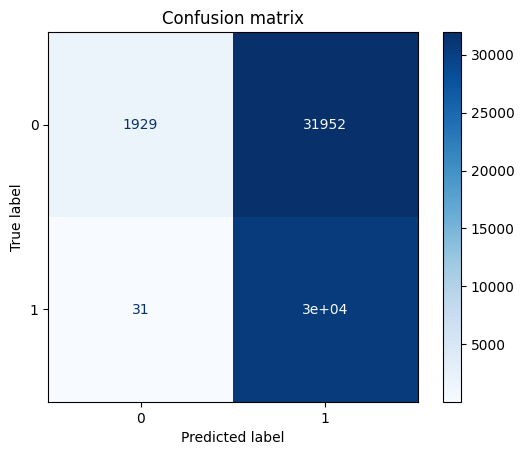

In [32]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion matrix")
plt.show()


## **ROC AUC**

In [33]:
from sklearn.metrics import roc_auc_score ,roc_curve

In [34]:
y_pred = rf.predict(X_test)

y_prob = rf.predict_proba(X_test)[:,1]

roc_score = roc_auc_score(y_test,y_prob)
print("ROC AUC :" ,roc_score)

ROC AUC : 0.607087333712037


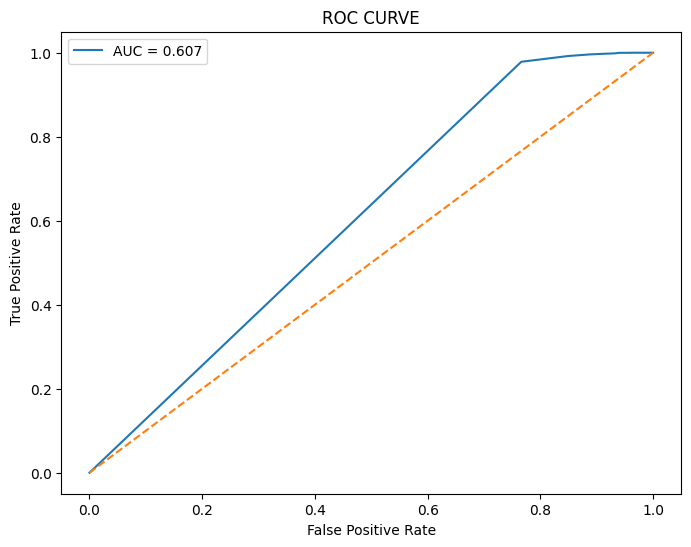

In [35]:
fpr , tpr ,threshold = roc_curve(y_test ,y_prob)
plt.figure(figsize = (8,6))
plt.plot(fpr, tpr, label = f"AUC = {roc_score:.3f}")

plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC CURVE")
plt.legend()
plt.show()

In [36]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier


In [37]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 19.5 MB/s eta 0:00:00


In [38]:
import optuna

**1) BASELINE MODEL**

In [39]:
model = XGBClassifier(random_state = 42)
model.fit(X_train , y_train)

y_pred = model.predict(X_test)

print("Baseline Accuarcy:", accuracy_score(y_test,y_pred))

Baseline Accuarcy: 0.5031689812657284


**2)Grid Search**

In [40]:
param_grid_corrected = {
    "n_estimators" : [50,100,150],
    "max_depth" : [3,5,7],
    "learning_rate" : [0.01,0.1]
}

grid = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric="logloss"),
    param_grid=param_grid_corrected,
    cv=3,
    scoring="accuracy")

grid.fit(X_train, y_train)

GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=True,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraints...
                                     learning_rate=None, max_bin=None,
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy')

**Random Search**

In [42]:
from sklearn.model_selection import RandomizedSearchCV

In [43]:
random_params = { 'n_estimators' : [50,100,150,200],
                 'max_depth' : [3,4,5,6,7],
                  'learning_rate' : [0.01,0.05,0.1,0.2]}

In [44]:
random_search = RandomizedSearchCV(estimator = XGBClassifier(random_state =42),param_distributions = random_params,n_iter =10 ,cv =3 ,random_state =42)

In [45]:
random_search.fit(X_train , y_train)
print(random_search.best_params_)
best_random = random_search.best_estimator_
prediction = best_random.predict(X_test)

print("Accuracy : ",accuracy_score(y_test ,prediction))

{'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.2}
Accuracy :  0.5033087892627458


**Optuna**

In [46]:
import optuna

In [52]:
def objectives(trial):
  model = XGBClassifier(
      n_estimators = trial.suggest_int("n_estimators" , 50,200),
      max_depth = trial.suggest_int("max_depth",3,7),
      learning_rate = trial.suggest_float("learning_rate",0.01,0.2),
      random_state =42
  )

  model.fit(X_train,y_train)
  prediction = model.predict(X_test)


  return accuracy_score(y_test,prediction)

study = optuna.create_study(direction = "maximize")
study.optimize(objectives , n_trials = 20)
print(study.best_params)
best_model = XGBClassifier(
    **study.best_params,
    random_state = 42
)
best_model.fit(X_train , y_train)
print("Accuarcy :",accuracy_score(y_test,prediction))

[I 2026-07-02 08:48:59,637] A new study created in memory with name: no-name-e8ebab6c-3664-4424-a611-5f33496290e7
[I 2026-07-02 08:49:09,998] Trial 0 finished with value: 0.483176437692236 and parameters: {'n_estimators': 148, 'max_depth': 7, 'learning_rate': 0.011945406795476213}. Best is trial 0 with value: 0.483176437692236.
[I 2026-07-02 08:49:14,671] Trial 1 finished with value: 0.5033243234846366 and parameters: {'n_estimators': 182, 'max_depth': 7, 'learning_rate': 0.10512555984583623}. Best is trial 1 with value: 0.5033243234846366.
[I 2026-07-02 08:49:19,808] Trial 2 finished with value: 0.49617858141485693 and parameters: {'n_estimators': 189, 'max_depth': 4, 'learning_rate': 0.07173621187691918}. Best is trial 1 with value: 0.5033243234846366.
[I 2026-07-02 08:49:24,702] Trial 3 finished with value: 0.4797589088762544 and parameters: {'n_estimators': 190, 'max_depth': 6, 'learning_rate': 0.011630702740687171}. Best is trial 1 with value: 0.5033243234846366.
[I 2026-07-02 08:

{'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.10184809333987582}
Accuarcy : 0.5033087892627458


## **Class Imbalance**

**Oversampling**

In [55]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state =42 )
x_sample ,y_sample = ros.fit_resample(X_train , y_train)

**Undersampling**

In [58]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_sample, y_sample = rus.fit_resample(X_train, y_train)

In [60]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(class_weight="balanced", random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [61]:
ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
model = XGBClassifier(scale_pos_weights = ratio , random_state =42)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:19:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "scale_pos_weights" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)